In [27]:
import os
os.environ["KERAS_BACKEND"] = "torch"

import json
import time
import keras
from keras.models import load_model
import numpy as np
# Necesario para TextVectorization y tf.data.
import tensorflow as tf
from models.training import compile_model, get_callbacks
from config.settings import get_settings
from features.embeddings import load_gensim_embeddings
from datasets.dataset import create_dataset
from features.vectorizer import build_vectorizer
from datasets.loader import load_splits
from models.model import SiameseLSTM
from evaluation.metrics import evaluate_model
from evaluation.visualization import plot_history
from models.similarity import l2_normalize, manhattan_similarity, cosine_similarity
from datasets.paths import (
	word2vec_path,
	embedding_path,
	vectorizer_path,
	augmented_dir,
	processed_dir,
	siamese_path,
	history_path,
    metrics_path,
    save_path
)


In [28]:
print(keras.config.backend())


torch


In [29]:
SEED = 42
np.random.seed(SEED)


In [30]:
settings = get_settings()

print(settings)


embed_dim=400 hidden_dim=64 batch_size=64 mlp_dropout=0.4 lstm_dropout=0.3 pooling='mean' similarity='cosine' mlp_layers=[64, 32] bidirectional=False concat_features=['diff'] epochs=20 siamese_name='lstm_mean_cosine_data'


In [31]:
use_augmented_data = False

if use_augmented_data:
	max_len = 27
	train_dir = augmented_dir
else:
	max_len = 26
	train_dir = processed_dir


In [ ]:
splits = {
	"train": train_dir,
	"dev": processed_dir,
    "test": processed_dir
}

datasets = load_splits(splits)

train_df = datasets["train"]
dev_df = datasets["dev"]
test_df = datasets["test"]


In [33]:
print("Train length:", len(train_df))
print("Dev length:", len(dev_df))


Train length: 15165
Dev length: 1497


In [17]:
all_sentences = list(train_df["sentence1"]) + list(train_df["sentence2"])

vectorizer = build_vectorizer(all_sentences, max_len)

vocab = vectorizer.get_vocabulary()
word2idx = {word: idx for idx, word in enumerate(vocab)}
print(f"Vocabulary size: {len(vocab)}")

vectorizer_model = keras.Sequential([vectorizer])
vectorizer_model.save(vectorizer_path)


Vocabulary size: 15886


c:\Users\malos\Documents\GitHub\JustShare\server\.venv\Lib\site-packages\keras\src\saving\saving_api.py:107: UserWarning: You are saving a model that has not yet been built. It might not contain any weights yet. Consider building the model first by calling it on some data.
  return saving_lib.save_model(model, filepath)


In [18]:
embedding_matrix = load_gensim_embeddings(word2vec_path, word2idx, settings.embed_dim)

np.save(embedding_path, embedding_matrix)


Found 15447/15886 words


In [19]:
train_dataset = create_dataset(train_df, vectorizer, settings.batch_size, shuffle=True)
dev_dataset = create_dataset(dev_df, vectorizer, settings.batch_size)


In [20]:
for (sent1, sent2), y in train_dataset.take(1):
	print("sent1:", sent1.shape)
	print("sent2:", sent2.shape)
	print("y:", y.shape)


sent1: (64, 26)
sent2: (64, 26)
y: (64,)


In [21]:
model = SiameseLSTM(
	vocab_size=len(vocab),
	embedding_dim=settings.embed_dim,
	hidden_dim=settings.hidden_dim,
	mlp_dropout=settings.mlp_dropout,
	lstm_dropout=settings.lstm_dropout,
	embedding_matrix=embedding_matrix,
	pooling=settings.pooling,
	similarity=settings.similarity,
	mlp_layers=settings.mlp_layers,
	bidirectional=settings.bidirectional,
	concat_features=settings.concat_features,
    name=settings.siamese_name
)


In [22]:
if model.mlp:
	model.mlp.summary()


In [23]:
head_model = model.get_head_model()
head_model.summary()


Model: "siamese_head"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_3         │ (None, None)      │          0 │ input_layer_1[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, None, 400) │  6,354,400 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cast_1 (Cast)       │ (None, None)      │          0 │ not_equal_3[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, None, 64)  │    119,040 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expand_dims_1       │ (None, None, 1)   │          0 │ cast_1[0][0]      │
│ (ExpandDims)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_1          │ (None, None, 64)  │          0 │ lstm_1[0][0],     │
│ (Multiply)          │                   │            │ expand_dims_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sum_3 (Sum)         │ (None, 1)         │          0 │ expand_dims_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sum_2 (Sum)         │ (None, 64)        │          0 │ multiply_1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 1)         │          0 │ sum_3[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ true_divide_1       │ (None, 64)        │          0 │ sum_2[0][0],      │
│ (TrueDivide)        │                   │            │ add_1[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 6,473,440 (24.69 MB)

 Trainable params: 119,040 (465.00 KB)

 Non-trainable params: 6,354,400 (24.24 MB)

In [24]:
dummy_sent1 = tf.zeros((1, max_len), dtype=tf.int32)
dummy_sent2 = tf.zeros((1, max_len), dtype=tf.int32)

model((dummy_sent1, dummy_sent2))

model.summary()


Model: "lstm_mean_cosine_data"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, None, 400)      │     6,354,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, None, 64)       │       119,040 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,473,440 (24.69 MB)

 Trainable params: 119,040 (465.00 KB)

 Non-trainable params: 6,354,400 (24.24 MB)

In [25]:
model = compile_model(model)

callbacks = get_callbacks(siamese_path)


In [26]:
start_time = time.perf_counter()

history = model.fit(
	train_dataset,
	validation_data=dev_dataset,
	epochs=settings.epochs,
	callbacks=callbacks
)

train_time = time.perf_counter() - start_time

np.save(history_path, history.history)


Epoch 1/20
 15/237 ━━━━━━━━━━━━━━━━━━━━ 1:39 450ms/step - loss: 0.0948 - mae: 0.2503 - rmse: 0.3436

KeyboardInterrupt: 

In [ ]:
embedding_matrix = np.load(embedding_path)

vectorizer_model = load_model(vectorizer_path)
vectorizer = vectorizer_model.layers[0]

custom_objects={
	"SiameseLSTM": SiameseLSTM,
	"l2_normalize": l2_normalize,
	"manhattan_similarity": manhattan_similarity,
	"cosine_similarity": cosine_similarity,
}

model = load_model(
	siamese_path,
	custom_objects=custom_objects,
	compile=False
)

model.embedding.set_weights([embedding_matrix])

head_model = model.get_head_model()

history_dict = np.load(history_path, allow_pickle=True).item()


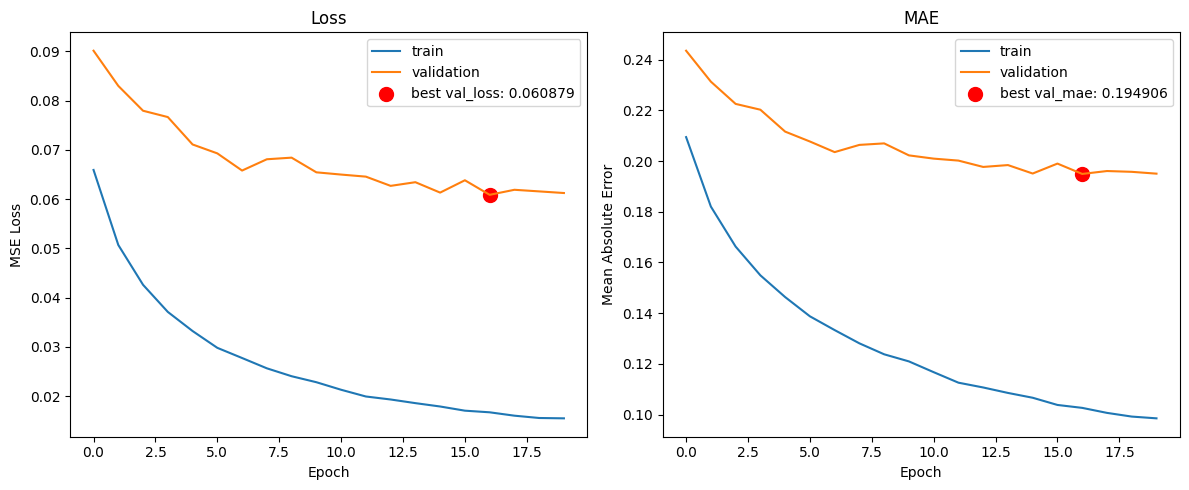

In [ ]:
history_metrics = plot_history(history_dict, save_path)


In [ ]:
test_dataset = create_dataset(test_df, vectorizer, settings.batch_size)

test_metrics = evaluate_model(model, test_dataset)


22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 252ms/step
Pearson: 0.6378 | Spearman: 0.6248 | MSE: 0.068383 | MAE: 0.202167 | RMSE: 0.261501 | R²: 0.2643


In [ ]:
metrics = {
    "Settings": model.name,
    "Hidden State": model.hidden_dim,
    "Embedding Dim": model.embedding_dim,
    "Pooling": model.pooling,
    "Similarity": model.similarity,
    "Bidirectional": model.bidirectional,
    "MLP Layers": model.mlp_layers,
    "Concat Features": model.concat_features,
    "MLP Dropout": model.mlp_dropout,
    "LSTM Dropout": model.lstm_dropout,
    
    "Sequence Length": max_len,
    "Data Augmentation": use_augmented_data,

    "Train Loss": history_metrics["train_loss"],
    "Train MAE": history_metrics["train_mae"],
    "Val Loss": history_metrics["val_loss"],
    "Val MAE": history_metrics["val_mae"],

    "Test Pearson": test_metrics["pearson"],
    "Test Spearman": test_metrics["spearman"],
    "Test MSE": test_metrics["mse"],
    "Test MAE": test_metrics["mae"],
    "Test RMSE": test_metrics["rmse"],
    "Test R2": test_metrics["r2"],

    "Train Time (s)": train_time
}

with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=4)
